In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm

from statsmodels.stats.multitest import multipletests

In [2]:
df = pd.read_csv('/home/valerie/Desktop/Master/metagenomics/HW3/input/cron_data.csv')

/tmp/ipykernel_10764/861376040.py:1: DtypeWarning: Columns (0: age_range, 1: artificial, 2: available_info, 3: collection_date_end, 4: diet, 5: intervention, 6: location, 7: medication, 8: medication_with_parents, 9: pmid, 10: smoker, 11: type_of_birth) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/home/valerie/Desktop/Master/metagenomics/HW3/input/cron_data.csv')


## Abundance table preparation

In [ ]:
species_cols = [col for col in df.columns if col.startswith('s__')]

clean_names = {col: col.split('.')[0].split('_SGB')[0] for col in species_cols}
abundance_table = df[species_cols].rename(columns=clean_names)
abundance_table = abundance_table.T.groupby(level=0).sum().T

metadata = df[[col for col in df.columns if not col.startswith('s__')]]

prevalence_threshold = 0.10
abundance_threshold = 0.001

prevalence = (abundance_table > 0).mean(axis=0)
mean_abundance = abundance_table.mean(axis=0)

keep_mask = (prevalence >= prevalence_threshold) & (mean_abundance >= abundance_threshold)
filtered_abundance = abundance_table.loc[:, keep_mask]

print(f"Original species count: {len(species_cols)}")
print(f"After deduplication: {abundance_table.shape[1]}")
print(f"After filtering: {filtered_abundance.shape[1]}")

Original species count: 3787
After deduplication: 3314
After filtering: 431


In [5]:
pseudocount = 1e-6
abundance_with_pseudo = filtered_abundance + pseudocount

def clr_transform(data):
    log_data = np.log(data)
    return log_data.sub(log_data.mean(axis=1), axis=0)

clr_abundance = clr_transform(abundance_with_pseudo)

final_mwas_df = pd.concat([metadata, clr_abundance], axis=1)

print("Data preparation complete. Ready for regression analysis.")
final_mwas_df.head()

Data preparation complete. Ready for regression analysis.


,sample_alias,age_category,age_range,age_years,artificial,available_info,bmi,collection_date,collection_date_end,diet,...,s__Veillonella_dispar,s__Veillonella_parvula,s__Veillonella_rogosae,s__Vescimonas,s__Vescimonas_coprocola,s__Victivallis_lenta,s__Wansuia_hejianensis,s__Wujia_chipingensis,s__Zhenpiania_hominis,s__bacterium_210917_DFI_7_65
0,Bai_2021_HIV.Q_H1,adult,NaN,29.0,NaN,NaN,NaN,2020-01-01,2020-12-31,NaN,...,-6.605268,-6.605268,-6.605268,-6.605268,5.503253,-6.605268,1.594746,4.905666,2.735311,4.104941
1,Bai_2021_HIV.Q_H10,adult,NaN,33.0,NaN,NaN,NaN,2020-01-01,2020-12-31,NaN,...,-4.353524,-4.353524,4.110480,-4.353524,7.189165,-4.353524,5.447987,-4.353524,2.770149,5.803093
2,Bai_2021_HIV.Q_H11,adult,NaN,30.0,NaN,NaN,NaN,2020-01-01,2020-12-31,NaN,...,-5.056455,-5.056455,-5.056455,-5.056455,8.397183,-5.056455,3.452907,7.548263,4.628317,5.472195
3,Bai_2021_HIV.Q_H2,adult,NaN,35.0,NaN,NaN,NaN,2020-01-01,2020-12-31,NaN,...,-5.135854,-5.135854,-5.135854,-5.135854,8.154632,6.889961,2.343445,-5.135854,4.016963,-5.135854
4,Bai_2021_HIV.Q_H3,adult,NaN,51.0,NaN,NaN,NaN,2020-01-01,2020-12-31,NaN,...,-6.042920,-6.042920,-6.042920,-6.042920,5.876810,-6.042920,-1.532061,2.843212,-6.042920,4.290432


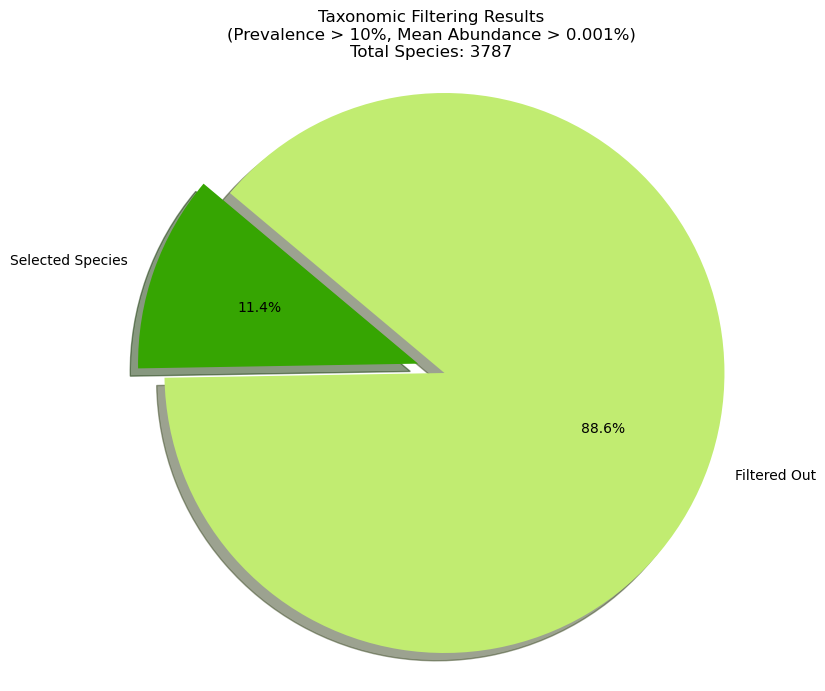

In [6]:
total_species = len(species_cols)
kept_species = filtered_abundance.shape[1]
filtered_out = total_species - kept_species

labels = ['Selected Species', 'Filtered Out']
sizes = [kept_species, filtered_out]
colors = ["#36a502", "#c1ec71"]
explode = (0.1, 0)

plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%',
        shadow=True, startangle=140, colors=colors)
plt.title(f"Taxonomic Filtering Results\n(Prevalence > 10%, Mean Abundance > 0.001%)\nTotal Species: {total_species}")
plt.axis('equal') 
plt.savefig('output/species_piechart.png', dpi=300)
plt.show()

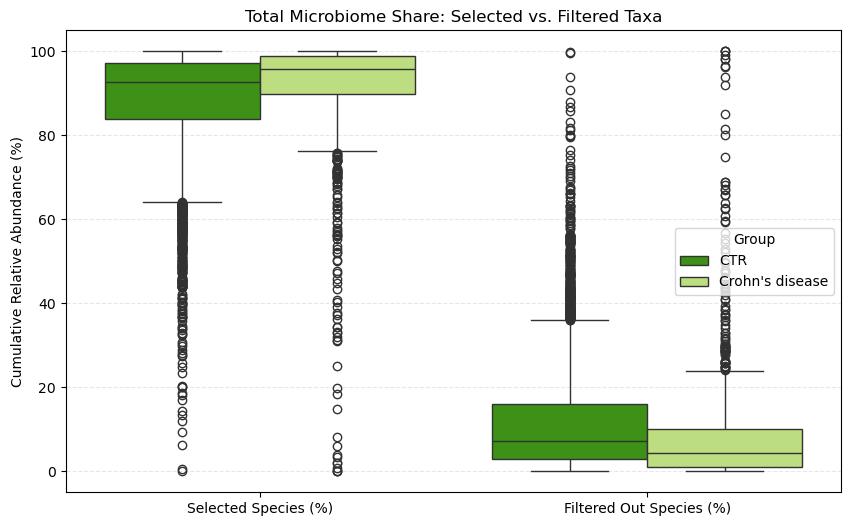

In [7]:
total_selected = abundance_table[filtered_abundance.columns].sum(axis=1)
total_filtered = abundance_table.drop(columns=filtered_abundance.columns).sum(axis=1)

agg_df = pd.DataFrame({
    'Status': final_mwas_df['subject_disease_status'],
    'Selected Species (%)': total_selected,
    'Filtered Out Species (%)': total_filtered
})

melted_agg = agg_df.melt(id_vars='Status', var_name='Category', value_name='Total Abundance')

plt.figure(figsize=(10, 6))
sns.boxplot(data=melted_agg, x='Category', y='Total Abundance', hue='Status', palette=colors)
plt.title("Total Microbiome Share: Selected vs. Filtered Taxa")
plt.ylabel("Cumulative Relative Abundance (%)")
plt.xlabel("")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(title='Group', loc='center right')
plt.savefig('output/microbiome_share_boxplot.png', dpi=300)
plt.show()

## MWAS with linear regression

In [8]:
mwas_data = final_mwas_df.copy()

mwas_data['is_crohns'] = (mwas_data['subject_disease_status'] == "Crohn's disease").astype(int)

results = []
species_to_test = [col for col in mwas_data.columns if col.startswith('s__')]

print(f"Will run MWAS on {len(mwas_data)} samples for {len(species_to_test)} species")

Will run MWAS on 5150 samples for 431 species


"does group membership predict species abundance?" 

In [ ]:
for species in species_to_test:
    formula = f"Q('{species}') ~ is_crohns + C(age_category) + C(sex)"
    try:
        model = smf.ols(formula, data=mwas_data).fit()
        results.append({
            'Species': species,
            'Beta': model.params['is_crohns'],
            'P_value': model.pvalues['is_crohns'],
            'Std_Err': model.bse['is_crohns']
        })
    except Exception as e:
        print(f"Skipped {species}: {e}")
        continue

mwas_results = pd.DataFrame(results)
# Use the Benjamini-Hochberg (FDR) method
_, fdr_p, _, _ = multipletests(mwas_results['P_value'], method='fdr_bh')
mwas_results['FDR_P'] = fdr_p

mwas_results = mwas_results.sort_values('FDR_P')

In [15]:
sig = mwas_results[mwas_results['FDR_P'] < 0.05]
print(f"Significant species after FDR correction: {len(sig)}") 

Significant species after FDR correction: 365


In [10]:
# Display the top 10 most significant results
print("\n--- Top 10 Significant Species Associated with Crohn's ---")
print(mwas_results.head(10))


--- Top 10 Significant Species Associated with Crohn's ---
                                Species      Beta        P_value   Std_Err  \
372             s__Phocaeicola_sartorii  3.315911  3.502523e-154  0.121116   
131   s__Enterocloster_clostridioformis  5.285612  4.791041e-152  0.194525   
3    s__Agathobaculum_butyriciproducens -3.955451  1.630242e-120  0.164977   
84   s__Clostridiales_bacterium_KLE1615 -4.252820  1.108253e-115  0.181309   
61                  s__Blautia_producta  3.597341   2.367804e-89  0.175990   
152          s__Faecalimonas_umbilicata  3.985223   2.810929e-88  0.196222   
195                          s__GGB3534  2.556643   1.119060e-83  0.129509   
290              s__Gemmiger_formicilis -4.228183   4.383350e-82  0.216378   
125      s__Eisenbergiella_massiliensis  3.379351   2.112593e-75  0.180901   
392              s__Ruminococcus_bromii -4.454194   2.073951e-74  0.240117   

             FDR_P  
372  1.509588e-151  
131  1.032469e-149  
3    2.342114e-118

In [11]:
mwas_results['-log10P'] = -np.log10(mwas_results['P_value'])
mwas_results = mwas_results.sort_values('Species')
mwas_results['Index'] = range(len(mwas_results))

# Standard alpha = 0.05
p_threshold = -np.log10(0.05)
# FDR threshold
fdr_sig_results = mwas_results[mwas_results['FDR_P'] < 0.05]
fdr_threshold = fdr_sig_results['-log10P'].min() if not fdr_sig_results.empty else None

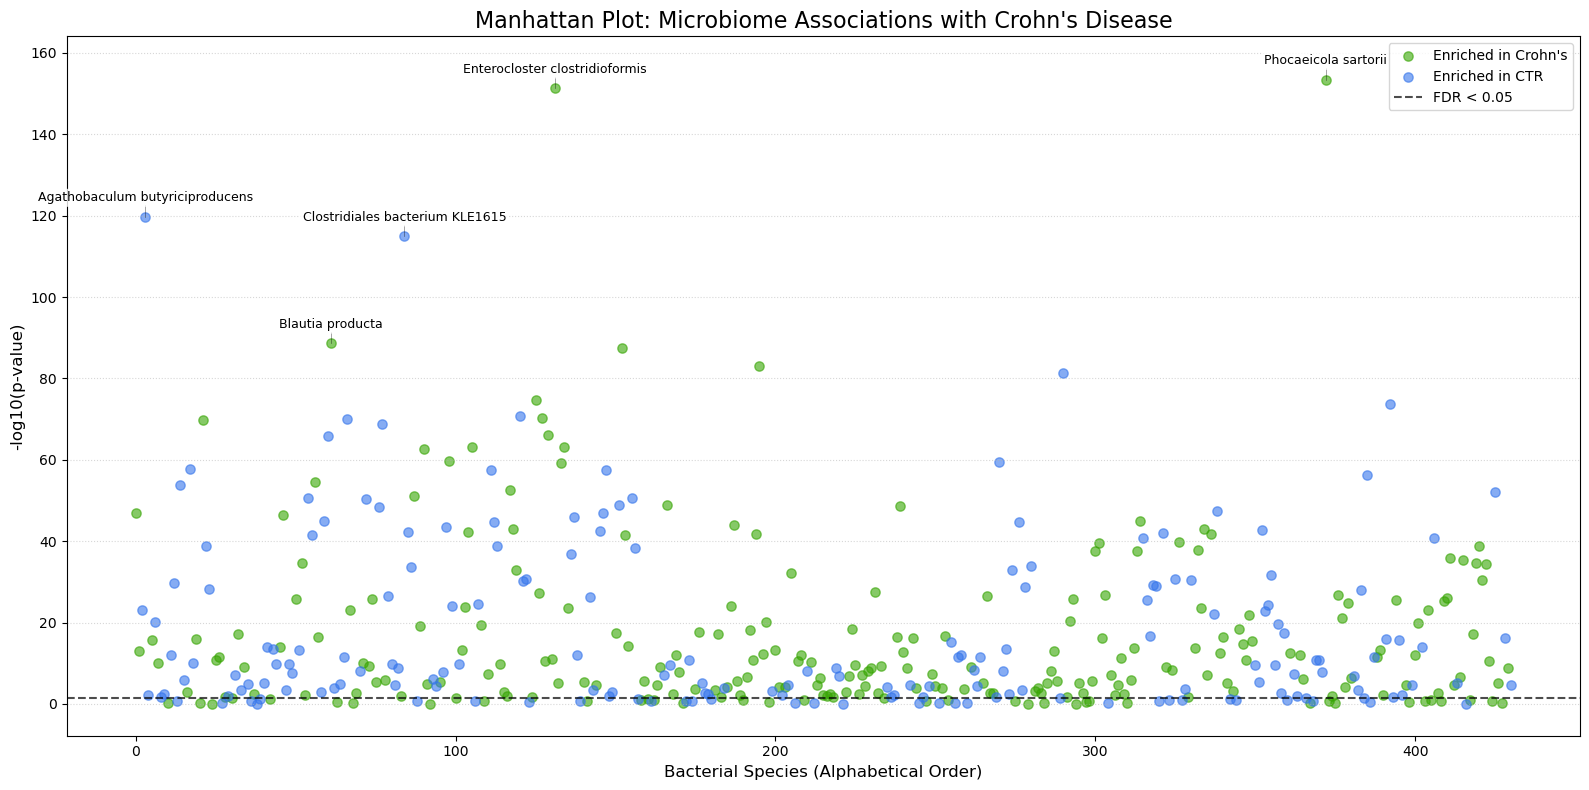

In [50]:
plt.figure(figsize=(16, 8))

crohns_hits = mwas_results[mwas_results['Beta'] > 0]
ctr_hits = mwas_results[mwas_results['Beta'] <= 0]

plt.scatter(crohns_hits['Index'], crohns_hits['-log10P'], 
            c='#36a502', alpha=0.6, s=45, label="Enriched in Crohn's")
plt.scatter(ctr_hits['Index'], ctr_hits['-log10P'], 
            c="#3575eb", alpha=0.6, s=45, label="Enriched in CTR")

# 4. Significance Line (FDR < 0.05)
if any(mwas_results['FDR_P'] < 0.05):
    fdr_threshold_p = mwas_results[mwas_results['FDR_P'] < 0.05]['P_value'].max()
    plt.axhline(-np.log10(fdr_threshold_p), color='black', linestyle='--', alpha=0.7, label='FDR < 0.05')

# 5. Label the Top 5 most significant species
top_5 = mwas_results.nsmallest(5, 'P_value')

for i, row in top_5.iterrows():
    # Clean the name (remove s__ and replace underscores)
    label_name = row['Species'].replace('s__', '').replace('_', ' ')
    
    plt.text(row['Index'], row['-log10P'] + 3, label_name, 
             fontsize=9, fontweight='normal', ha='center', va='bottom',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))
    
    # Draw a thin line connecting the label to the point
    plt.plot([row['Index'], row['Index']], [row['-log10P'], row['-log10P'] + 2.8], 
             color='black', lw=0.5, alpha=0.5)

# 6. Formatting
plt.title("Manhattan Plot: Microbiome Associations with Crohn's Disease", fontsize=16)
plt.xlabel("Bacterial Species (Alphabetical Order)", fontsize=12)
plt.ylabel("-log10(p-value)", fontsize=12)
plt.legend(loc='upper right', frameon=True)
plt.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('output/linear_manhattan.png', dpi=300)
plt.show()

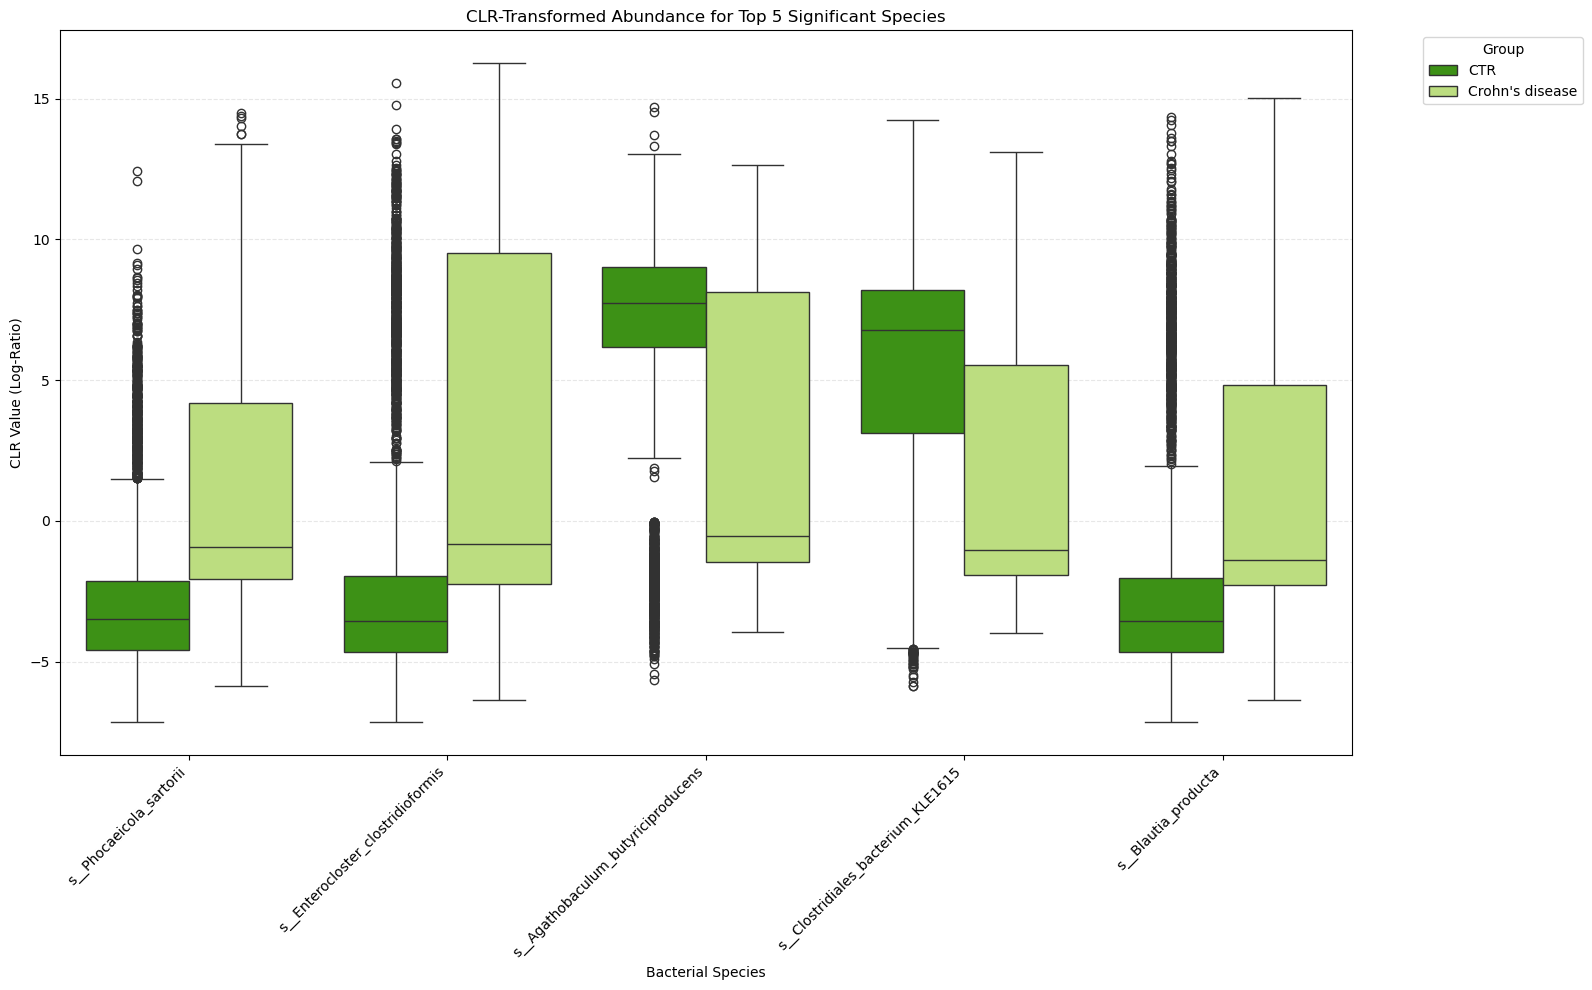

In [18]:
top_species = mwas_results.nsmallest(5, 'FDR_P')['Species'].tolist()

plot_df = mwas_data[['subject_disease_status'] + top_species].melt(
    id_vars='subject_disease_status', 
    var_name='Species', 
    value_name='CLR_Abundance'
)

plt.figure(figsize=(16, 10))
sns.boxplot(data=plot_df, x='Species', y='CLR_Abundance', hue='subject_disease_status', palette=colors)

# Clean up formatting
plt.xticks(rotation=45, ha='right')
plt.title("CLR-Transformed Abundance for Top 5 Significant Species")
plt.ylabel("CLR Value (Log-Ratio)")
plt.xlabel("Bacterial Species")
plt.legend(title='Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('output/linear_boxplots.png', dpi=300)
plt.show()

## MWAS with logistic regression

In [19]:
# 1 = species present (abundance > 0), 0 = absent
binary_abundance = (filtered_abundance > 0).astype(int)

binary_mwas_df = pd.concat([metadata, binary_abundance], axis=1)
binary_mwas_df['is_crohns'] = (binary_mwas_df['subject_disease_status'] == "Crohn's disease").astype(int)

print(f"Binary table shape: {binary_abundance.shape}")
print(f"Sample preview:\n{binary_abundance.iloc[:3, :5]}")

Binary table shape: (5150, 431)
Sample preview:
   s__Acidaminococcus_intestini  s__Actinomyces_sp_ICM47  \
0                             0                        0   
1                             0                        1   
2                             0                        1   

   s__Adlercreutzia_equolifaciens  s__Agathobaculum_butyriciproducens  \
0                               1                                   1   
1                               1                                   1   
2                               0                                   1   

   s__Akkermansia_muciniphila  
0                           1  
1                           0  
2                           0  


In [21]:
logit_results = []
species_to_test_bin = [col for col in binary_mwas_df.columns if col.startswith('s__')]

print(f"Running logistic MWAS on {len(binary_mwas_df)} samples for {len(species_to_test_bin)} species...")

for species in species_to_test_bin:
    # Skip species with no variance (all 0s or all 1s) — logistic regression will fail
    if binary_mwas_df[species].nunique() < 2:
        print(f"Skipped (no variance): {species}")
        continue
    
    formula = f"is_crohns ~ Q('{species}') + C(age_category) + C(sex)"
    try:
        model = smf.logit(formula, data=binary_mwas_df).fit(disp=0)  # disp=0 suppresses iteration logs
        logit_results.append({
            'Species': species,
            'Beta':    model.params[f"Q('{species}')"],
            'P_value': model.pvalues[f"Q('{species}')"],
            'Std_Err': model.bse[f"Q('{species}')"],
            'OR':      np.exp(model.params[f"Q('{species}')"]),  # Odds Ratio
        })
    except Exception as e:
        print(f"Skipped {species}: {e}")
        continue

logit_mwas_results = pd.DataFrame(logit_results)

# FDR correction
_, fdr_p, _, _ = multipletests(logit_mwas_results['P_value'], method='fdr_bh')
logit_mwas_results['FDR_P'] = fdr_p

logit_mwas_results = logit_mwas_results.sort_values('FDR_P')

print(f"\nDone. Significant species (FDR < 0.05): {(logit_mwas_results['FDR_P'] < 0.05).sum()}")
print("\n--- Top 10 Most Significant Species ---")
print(logit_mwas_results.head(10))

Running logistic MWAS on 5150 samples for 431 species...

Done. Significant species (FDR < 0.05): 403

--- Top 10 Most Significant Species ---
                                   Species      Beta        P_value   Std_Err  \
3       s__Agathobaculum_butyriciproducens -2.212285  2.584431e-135  0.089359   
84      s__Clostridiales_bacterium_KLE1615 -2.265693  7.322468e-129  0.093814   
60                        s__Blautia_obeum -1.913166  2.906280e-109  0.086150   
120               s__Dorea_formicigenerans -1.927331  4.369602e-108  0.087267   
66           s__Brotolimicola_acetigignens -1.908760  4.221812e-106  0.087246   
392                 s__Ruminococcus_bromii -1.996760  5.231686e-104  0.092200   
290                 s__Gemmiger_formicilis -1.981490  2.419846e-103  0.091794   
54                       s__Blautia_faecis -2.017634  2.788809e-103  0.093497   
147        s__Faecalibacterium_prausnitzii -2.195288  2.031706e-102  0.102165   
77   s__Clostridiaceae_bacterium_AF18_31LB -1.9

In [53]:
sig_strict = logit_mwas_results[
    (logit_mwas_results['FDR_P'] < 0.05) & 
    (logit_mwas_results['Beta'].abs() > 0.5)  # meaningful log-odds effect
]
print(f"Significant + meaningful effect size: {len(sig_strict)}")

Significant + meaningful effect size: 370


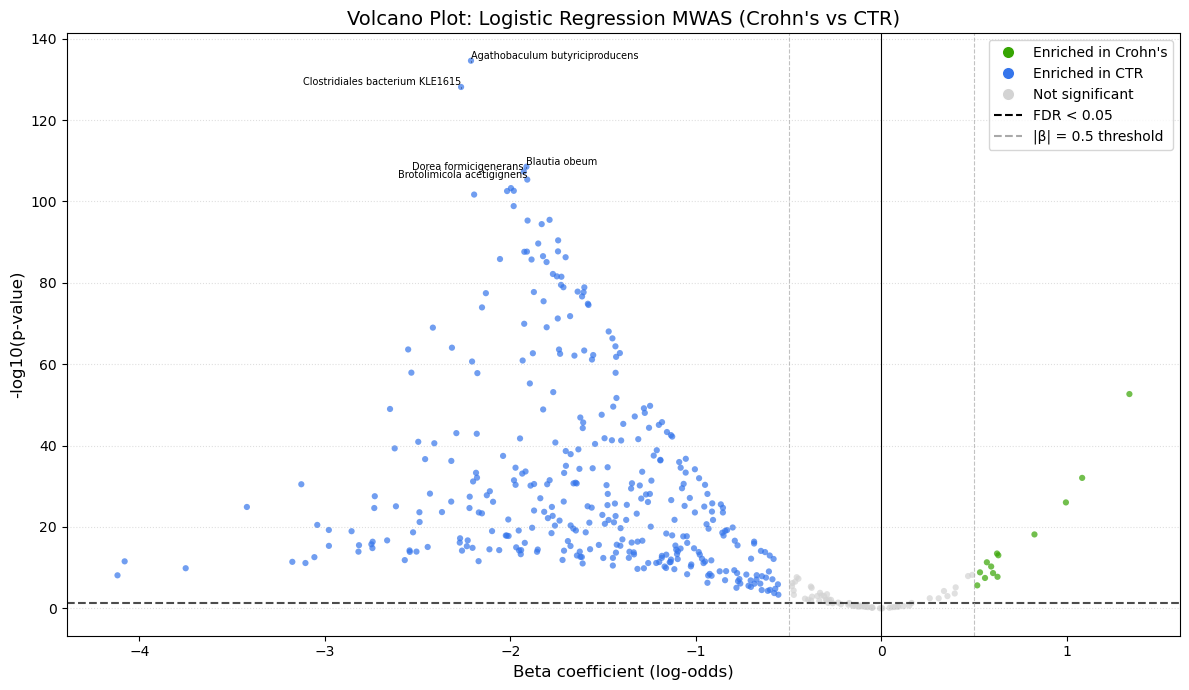

In [ ]:
logit_mwas_results['-log10P'] = -np.log10(logit_mwas_results['P_value'])

# Color by significance and direction
def assign_color(row):
    if row['FDR_P'] < 0.05 and abs(row['Beta']) > 0.5:
        return '#36a502' if row['Beta'] > 0 else '#3575eb'
    return 'lightgrey'

logit_mwas_results['color'] = logit_mwas_results.apply(assign_color, axis=1)

sig_hits = logit_mwas_results[logit_mwas_results['FDR_P'] < 0.05]
fdr_line = sig_hits['-log10P'].min() if not sig_hits.empty else None

plt.figure(figsize=(12, 7))

plt.scatter(
    logit_mwas_results['Beta'],
    logit_mwas_results['-log10P'],
    c=logit_mwas_results['color'],
    alpha=0.7, s=20, edgecolors='none'
)

plt.axvline(0, color='black', linewidth=0.8, linestyle='-')
if fdr_line:
    plt.axhline(fdr_line, color='black', linestyle='--', alpha=0.7, label='FDR < 0.05')

# Label top 5 most significant
top5 = logit_mwas_results.nsmallest(5, 'P_value').sort_values('Beta')

for i, (_, row) in enumerate(top5.iterrows()):
    label = row['Species'].replace('s__', '').replace('_', ' ')
    y_label = row['-log10P']
    ha = 'right' if i % 2 == 0 else 'left'

    plt.text(row['Beta'], y_label, label,
             fontsize=7, fontweight='normal', ha=ha, va='bottom')
    
    plt.plot([row['Beta'], row['Beta']], [row['-log10P'], y_label - 0.2],
             color='black', lw=0.5, alpha=0.5)

# Legend proxies
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#36a502',   markersize=9, label="Enriched in Crohn's"),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#3575eb',  markersize=9, label='Enriched in CTR'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgrey',markersize=9, label='Not significant'),
    Line2D([0], [0], color='black', linestyle='--', label='FDR < 0.05'),
    Line2D([0], [0], color='darkgrey', linestyle='--', label='|β| = 0.5 threshold'),
]
plt.legend(handles=legend_elements, loc='upper right')
plt.axvline(0.5,  color='darkgrey', linewidth=0.8, linestyle='--', alpha=0.7)
plt.axvline(-0.5, color='darkgrey', linewidth=0.8, linestyle='--', alpha=0.7)
plt.title("Volcano Plot: Logistic Regression MWAS (Crohn's vs CTR)", fontsize=14)
plt.xlabel("Beta coefficient (log-odds)", fontsize=12)
plt.ylabel("-log10(p-value)", fontsize=12)
plt.grid(axis='y', linestyle=':', alpha=0.4)
plt.tight_layout()
plt.savefig('output/logistic_volcano_plot.png', dpi=300)
plt.show()